In [4]:
from google.colab import files
uploaded = files.upload()

Saving oncologists_nyc.csv to oncologists_nyc.csv


In [8]:
import pandas as pd
from google.colab import files
import os

# Check if file exists, if not, prompt for upload
if not os.path.exists('oncologists_nyc.csv'):
    print("oncologists_nyc.csv not found. Please upload the file.")
    uploaded = files.upload()

df = pd.read_csv('oncologists_nyc.csv')
display(df.head())

oncologists_nyc.csv not found. Please upload the file.


Saving oncologists_nyc.csv to oncologists_nyc.csv


,place_id,name,categoryName,categories,address,street,city,state,countryCode,phone,website,reviewsCount,url
0,ChIJlZ4P8qb3wokRwmH1-7F0TEM,"David P. Horowitz, MD",Oncologist,Oncologist | Doctor,"622 W 168th St, New York, New York",622 W 168th St,New York,New York,US,(212) 305-5050,https://doctors.columbia.edu/us/ny/new-york/da...,25.0,https://www.google.com/maps/search/?api=1&quer...
1,ChIJt0Cwr8NYwokRkcRGZZXzdwY,"Simon Mantha, MD, MPH - MSK Hematologist",Hematologist,Hematologist | Oncologist,"530 E 74th St, New York, New York",530 E 74th St,New York,New York,US,(347) 798-9075,https://www.mskcc.org/cancer-care/doctors/simo...,6.0,https://www.google.com/maps/search/?api=1&quer...
2,ChIJ5e4Fr8NYwokRZsZqlYUs7Tc,"M.H. Heinemann, MD, FACS - MSK Ophthalmic Onco...",Surgical oncologist,Surgical oncologist | Oncologist,"1275 York Ave, New York, New York",1275 York Ave,New York,New York,US,(347) 971-4218,https://www.mskcc.org/cancer-care/doctors/m-h-...,11.0,https://www.google.com/maps/search/?api=1&quer...
3,ChIJM9jpmpv2wokRn6TuN7FKa-4,Tumor Immunotherapy Program at NewYork-Presbyt...,Health,Health | Doctor | Medical office | Surgeon,"177 Fort Washington Ave, New York, New York",177 Fort Washington Ave,New York,New York,US,(800) 227-2762,NaN,NaN,https://www.google.com/maps/search/?api=1&quer...
4,ChIJV6yNyIz1wokRQYlj4_oUviU,"Mark H. Chaitowitz, MD",Hematologist,Hematologist | Oncologist,"1695 Eastchester Rd, Bronx, New York",1695 Eastchester Rd,Bronx,New York,US,(718) 405-8505,https://montefioreeinstein.org/profiles/192221...,1.0,https://www.google.com/maps/search/?api=1&quer...


In [6]:
import pandas as pd
df = pd.read_csv('oncologists_nyc.csv')
df.shape

(640, 13)

In [8]:
df.columns

Index(['place_id', 'name', 'categoryName', 'categories', 'address', 'street',
       'city', 'state', 'countryCode', 'phone', 'website', 'reviewsCount',
       'url'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   place_id      640 non-null    object 
 1   name          640 non-null    object 
 2   categoryName  640 non-null    object 
 3   categories    640 non-null    object 
 4   address       640 non-null    object 
 5   street        640 non-null    object 
 6   city          640 non-null    object 
 7   state         640 non-null    object 
 8   countryCode   640 non-null    object 
 9   phone         637 non-null    object 
 10  website       562 non-null    object 
 11  reviewsCount  503 non-null    float64
 12  url           640 non-null    object 
dtypes: float64(1), object(12)
memory usage: 65.1+ KB


In [11]:
df.isnull().sum()

,0
place_id,0
name,0
categoryName,0
categories,0
address,0
street,0
city,0
state,0
countryCode,0
phone,3


In [12]:
df.describe()

,reviewsCount
count,503.000000
mean,61.095427
std,176.930476
min,1.000000
25%,4.000000
50%,11.000000
75%,39.000000
max,2314.000000


In [13]:
df.describe(include='object')

,place_id,name,categoryName,categories,address,street,city,state,countryCode,phone,website,url
count,640,640,640,640,640,640,640,640,640,637,562,640
unique,640,631,36,124,263,262,16,2,1,415,547,640
top,ChIJoxdk2HhiwokRlUXYvD-RiMA,"Evelyn Toyin Taiwo, M.D.",Oncologist,Oncologist,"160 E 53rd St, New York, New York",160 E 53rd St,New York,New York,US,(212) 305-5098,https://nyulangone.org/doctors,https://www.google.com/maps/search/?api=1&quer...
freq,1,3,258,160,52,52,403,629,640,36,4,1


In [14]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='categoryName'>

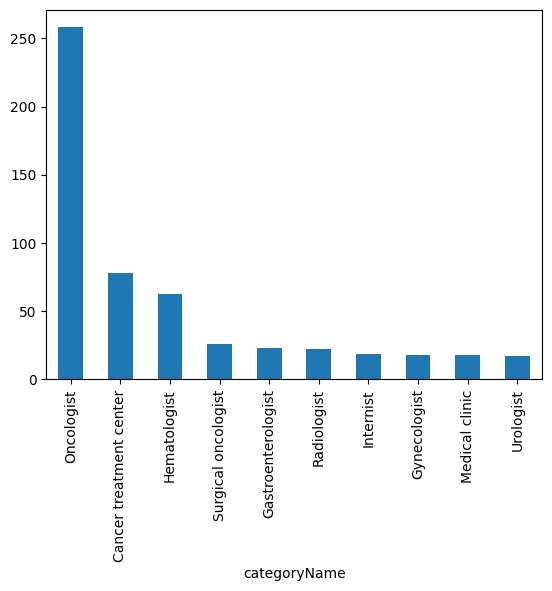

In [17]:
df['categoryName'].value_counts().head(10).plot(kind="bar")

<Axes: >

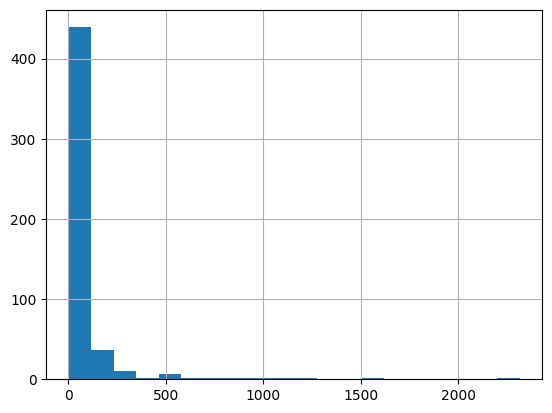

In [19]:
df["reviewsCount"].hist(bins=20)

<Axes: >

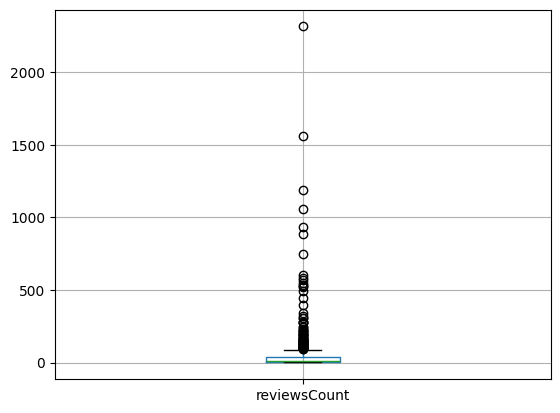

In [21]:
df.boxplot(column="reviewsCount")

In [22]:
numeric_cols= df.select_dtypes(include="number")

numeric_cols.corr()

,reviewsCount
reviewsCount,1.0


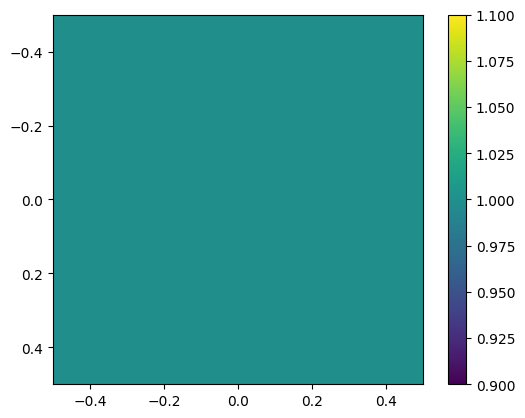

In [23]:
import matplotlib.pyplot as plt

plt.imshow(numeric_cols.corr())
plt.colorbar()
plt.show()

In [43]:
!pip install duckdb

In [44]:
import pandas as pd
import duckdb

df = pd.read_csv("oncologists_nyc.csv")

In [45]:
duckdb.register("oncology", df)

In [46]:
df.columns.tolist()

['place_id',
 'name',
 'categoryName',
 'categories',
 'address',
 'street',
 'city',
 'state',
 'countryCode',
 'phone',
 'website',
 'reviewsCount',
 'url']

In [47]:
duckdb.sql("""
SELECT *
FROM oncology
LIMIT 10
""").df()

,place_id,name,categoryName,categories,address,street,city,state,countryCode,phone,website,reviewsCount,url
0,ChIJlZ4P8qb3wokRwmH1-7F0TEM,"David P. Horowitz, MD",Oncologist,Oncologist | Doctor,"622 W 168th St, New York, New York",622 W 168th St,New York,New York,US,(212) 305-5050,https://doctors.columbia.edu/us/ny/new-york/da...,25.0,https://www.google.com/maps/search/?api=1&quer...
1,ChIJt0Cwr8NYwokRkcRGZZXzdwY,"Simon Mantha, MD, MPH - MSK Hematologist",Hematologist,Hematologist | Oncologist,"530 E 74th St, New York, New York",530 E 74th St,New York,New York,US,(347) 798-9075,https://www.mskcc.org/cancer-care/doctors/simo...,6.0,https://www.google.com/maps/search/?api=1&quer...
2,ChIJ5e4Fr8NYwokRZsZqlYUs7Tc,"M.H. Heinemann, MD, FACS - MSK Ophthalmic Onco...",Surgical oncologist,Surgical oncologist | Oncologist,"1275 York Ave, New York, New York",1275 York Ave,New York,New York,US,(347) 971-4218,https://www.mskcc.org/cancer-care/doctors/m-h-...,11.0,https://www.google.com/maps/search/?api=1&quer...
3,ChIJM9jpmpv2wokRn6TuN7FKa-4,Tumor Immunotherapy Program at NewYork-Presbyt...,Health,Health | Doctor | Medical office | Surgeon,"177 Fort Washington Ave, New York, New York",177 Fort Washington Ave,New York,New York,US,(800) 227-2762,None,NaN,https://www.google.com/maps/search/?api=1&quer...
4,ChIJV6yNyIz1wokRQYlj4_oUviU,"Mark H. Chaitowitz, MD",Hematologist,Hematologist | Oncologist,"1695 Eastchester Rd, Bronx, New York",1695 Eastchester Rd,Bronx,New York,US,(718) 405-8505,https://montefioreeinstein.org/profiles/192221...,1.0,https://www.google.com/maps/search/?api=1&quer...
5,ChIJFfhMCPVZwokR-a_dNoFYmb4,"Puneeth Iyengar, MD, PhD - MSK Radiation Oncol...",Radiologist,Radiologist | Oncologist,"1275 York Ave, New York, New York",1275 York Ave,New York,New York,US,(212) 639-5159,https://www.mskcc.org/cancer-care/doctors/pune...,NaN,https://www.google.com/maps/search/?api=1&quer...
6,ChIJg35nCo73wokRwN5kBPylbQI,Columbia Herbert Irving Cancer Center - Kidney...,Cancer treatment center,Cancer treatment center | Oncologist,"Herbert Irving Comprehensive Cancer Center, 16...","Herbert Irving Comprehensive Cancer Center, 16...",New York,New York,US,(212) 305-5098,https://www.cancer.columbia.edu/cancer-types-c...,NaN,https://www.google.com/maps/search/?api=1&quer...
7,ChIJocRqwCDzwokRmgj7C-ojgyk,"Della F. Makower, MD",Hematologist,Hematologist | Oncologist,"1695 Eastchester Rd, Bronx, New York",1695 Eastchester Rd,Bronx,New York,US,(718) 405-8505,https://doctors.montefioreeinstein.org/provide...,NaN,https://www.google.com/maps/search/?api=1&quer...
8,ChIJRaWSATmUwokRPjgqdupCbHo,"Della F. Makower, MD",Hematologist,Hematologist | Oncologist,"1575 Blondell Ave, Bronx, New York",1575 Blondell Ave,Bronx,New York,US,(718) 862-8840,https://doctors.montefioreeinstein.org/provide...,NaN,https://www.google.com/maps/search/?api=1&quer...
9,ChIJMSqOq630wokRpsTHrBWHVMI,"Anna Ferrari, MD, MD",Oncologist,Oncologist,"1695 Eastchester Rd, Bronx, New York",1695 Eastchester Rd,Bronx,New York,US,(718) 405-8430,None,NaN,https://www.google.com/maps/search/?api=1&quer...


In [48]:
duckdb.sql("""
SELECT name, categoryName
FROM oncology
LIMIT 10
""").df()

,name,categoryName
0,"David P. Horowitz, MD",Oncologist
1,"Simon Mantha, MD, MPH - MSK Hematologist",Hematologist
2,"M.H. Heinemann, MD, FACS - MSK Ophthalmic Onco...",Surgical oncologist
3,Tumor Immunotherapy Program at NewYork-Presbyt...,Health
4,"Mark H. Chaitowitz, MD",Hematologist
5,"Puneeth Iyengar, MD, PhD - MSK Radiation Oncol...",Radiologist
6,Columbia Herbert Irving Cancer Center - Kidney...,Cancer treatment center
7,"Della F. Makower, MD",Hematologist
8,"Della F. Makower, MD",Hematologist
9,"Anna Ferrari, MD, MD",Oncologist


In [49]:
duckdb.sql("""
SELECT COUNT(*) AS total_records
FROM oncology
""").df()

,total_records
0,640


In [50]:
duckdb.sql("""
SELECT
    categoryName,
    COUNT(*) AS total
FROM oncology
GROUP BY categoryName
ORDER BY total DESC
""").df()

,categoryName,total
0,Oncologist,258
1,Cancer treatment center,78
2,Hematologist,63
3,Surgical oncologist,26
4,Gastroenterologist,23
5,Radiologist,22
6,Internist,19
7,Medical clinic,18
8,Gynecologist,18
9,Urologist,17


In [52]:
duckdb.sql("""
SELECT COUNT(*) AS total_records
FROM oncology
""").df()

,total_records
0,640


In [53]:
duckdb.sql("""
SELECT COUNT(DISTINCT categoryName) AS total_categories
FROM oncology
""").df()

,total_categories
0,36


In [54]:
duckdb.sql("""
SELECT
    categoryName,
    COUNT(*) AS total
FROM oncology
GROUP BY categoryName
ORDER BY total DESC
LIMIT 10
""").df()

,categoryName,total
0,Oncologist,258
1,Cancer treatment center,78
2,Hematologist,63
3,Surgical oncologist,26
4,Gastroenterologist,23
5,Radiologist,22
6,Internist,19
7,Gynecologist,18
8,Medical clinic,18
9,Doctor,17


In [55]:
duckdb.sql("""
SELECT
    state,
    COUNT(*) AS total
FROM oncology
GROUP BY state
ORDER BY total DESC
""").df()

,state,total
0,New York,629
1,NY,11


In [56]:
duckdb.sql("""
SELECT
    city,
    COUNT(*) AS total
FROM oncology
GROUP BY city
ORDER BY total DESC
LIMIT 20
""").df()

,city,total
0,New York,403
1,Brooklyn,126
2,Staten Island,41
3,Bronx,30
4,Flushing,7
5,Rego Park,7
6,Elmhurst,6
7,Forest Hills,6
8,Jamaica,4
9,Fresh Meadows,2


In [57]:
duckdb.sql("""
SELECT
    categoryName,
    COUNT(*) AS total
FROM oncology
GROUP BY categoryName
HAVING COUNT(*) > 10
ORDER BY total DESC
""").df()

,categoryName,total
0,Oncologist,258
1,Cancer treatment center,78
2,Hematologist,63
3,Surgical oncologist,26
4,Gastroenterologist,23
5,Radiologist,22
6,Internist,19
7,Medical clinic,18
8,Gynecologist,18
9,Urologist,17


In [58]:
duckdb.sql("""
SELECT
    name,
    reviewsCount,
    CASE
        WHEN reviewsCount >= 100 THEN 'High'
        WHEN reviewsCount >= 30 THEN 'Medium'
        ELSE 'Low'
    END AS popularity
FROM oncology
""").df()

,name,reviewsCount,popularity
0,"David P. Horowitz, MD",25.0,Low
1,"Simon Mantha, MD, MPH - MSK Hematologist",6.0,Low
2,"M.H. Heinemann, MD, FACS - MSK Ophthalmic Onco...",11.0,Low
3,Tumor Immunotherapy Program at NewYork-Presbyt...,NaN,Low
4,"Mark H. Chaitowitz, MD",1.0,Low
...,...,...,...
635,"Daniel T. Friedman, MD",3.0,Low
636,Hematology & Oncology PLLC,3.0,Low
637,Bruckner Howard W MD,6.0,Low
638,Montefiore Einstein Comprehensive Cancer Center,30.0,Medium


In [7]:
import duckdb
import pandas as pd
import os
from google.colab import files

# Check if file exists, if not, prompt for upload
if not os.path.exists('oncologists_nyc.csv'):
    print("oncologists_nyc.csv not found. Please upload the file.")
    uploaded = files.upload()

df = pd.read_csv('oncologists_nyc.csv')
duckdb.register("oncology", df)
duckdb.sql("""
SELECT
    name,
    categoryName,
    COALESCE(reviewsCount, 0) AS reviewsCount
FROM oncology
LIMIT 10
""").df()

oncologists_nyc.csv not found. Please upload the file.


Saving oncologists_nyc.csv to oncologists_nyc.csv


,name,categoryName,reviewsCount
0,"David P. Horowitz, MD",Oncologist,25.0
1,"Simon Mantha, MD, MPH - MSK Hematologist",Hematologist,6.0
2,"M.H. Heinemann, MD, FACS - MSK Ophthalmic Onco...",Surgical oncologist,11.0
3,Tumor Immunotherapy Program at NewYork-Presbyt...,Health,0.0
4,"Mark H. Chaitowitz, MD",Hematologist,1.0
5,"Puneeth Iyengar, MD, PhD - MSK Radiation Oncol...",Radiologist,0.0
6,Columbia Herbert Irving Cancer Center - Kidney...,Cancer treatment center,0.0
7,"Della F. Makower, MD",Hematologist,0.0
8,"Della F. Makower, MD",Hematologist,0.0
9,"Anna Ferrari, MD, MD",Oncologist,0.0


In [8]:
duckdb.sql("""
SELECT
    name,
    categoryName,
    reviewsCount,
    ROW_NUMBER() OVER(
        PARTITION BY categoryName
        ORDER BY reviewsCount DESC
    ) AS row_num
FROM oncology
""").df()

,name,categoryName,reviewsCount,row_num
0,"Alan B. Astrow, M.D.",Internist,19.0,1
1,Addeo Joseph N MD,Internist,11.0,2
2,"Dr. Joseph F. Hederman, MD",Internist,7.0,3
3,"Yevgeniy Skaradinskiy, DO",Internist,6.0,4
4,Bruckner Howard W MD,Internist,6.0,5
...,...,...,...,...
635,The New York Eye Cancer Center: Paul T. Finger MD,Ophthalmologist,16.0,2
636,"Sergio A. Giralt, MD - MSK Bone Marrow Transpl...",Transplant surgeon,17.0,1
637,"Heather J. Landau, MD - MSK Bone Marrow Transp...",Transplant surgeon,14.0,2
638,"Mohammad Maher Abdul Hay, MD",Transplant surgeon,14.0,3


In [9]:
duckdb.sql("""
SELECT
    name,
    categoryName,
    reviewsCount,
    RANK() OVER(
        PARTITION BY categoryName
        ORDER BY reviewsCount DESC
    ) AS ranking
FROM oncology
""").df()

,name,categoryName,reviewsCount,ranking
0,"Daniel J. Alpert, M.D.",Gastroenterologist,193.0,1
1,"Yelena Y. Janjigian, MD - MSK Gastrointestinal...",Gastroenterologist,34.0,2
2,"Imane El Dika, MD - MSK Gastrointestinal Medic...",Gastroenterologist,24.0,3
3,"Leonard Saltz, MD - MSK Gastrointestinal Oncol...",Gastroenterologist,22.0,4
4,"Anna M. Varghese, MD - MSK Gastrointestinal Me...",Gastroenterologist,19.0,5
...,...,...,...,...
635,"Jene Marie Tesoriero, MD",Pediatrician,4.0,5
636,"Dr. Yaoping Zhang, MD",Pediatrician,NaN,6
637,Children's Center For Cancer: Hogan Laura MD,Pediatrician,NaN,6
638,"Dr. Jaclyn C. Davis, MD",Pediatrician,NaN,6


In [10]:
duckdb.sql("""
SELECT
    name,
    categoryName,
    reviewsCount,
    DENSE_RANK() OVER(
        PARTITION BY categoryName
        ORDER BY reviewsCount DESC
    ) AS dense_rank
FROM oncology
""").df()

,name,categoryName,reviewsCount,dense_rank
0,"Daniel J. Alpert, M.D.",Gastroenterologist,193.0,1
1,"Yelena Y. Janjigian, MD - MSK Gastrointestinal...",Gastroenterologist,34.0,2
2,"Imane El Dika, MD - MSK Gastrointestinal Medic...",Gastroenterologist,24.0,3
3,"Leonard Saltz, MD - MSK Gastrointestinal Oncol...",Gastroenterologist,22.0,4
4,"Anna M. Varghese, MD - MSK Gastrointestinal Me...",Gastroenterologist,19.0,5
...,...,...,...,...
635,The New York Eye Cancer Center: Paul T. Finger MD,Ophthalmologist,16.0,2
636,"Sergio A. Giralt, MD - MSK Bone Marrow Transpl...",Transplant surgeon,17.0,1
637,"Heather J. Landau, MD - MSK Bone Marrow Transp...",Transplant surgeon,14.0,2
638,"Mohammad Maher Abdul Hay, MD",Transplant surgeon,14.0,2


In [11]:
duckdb.sql("""
SELECT *
FROM (
    SELECT
        name,
        categoryName,
        reviewsCount,
        RANK() OVER(
            PARTITION BY categoryName
            ORDER BY reviewsCount DESC
        ) AS ranking
    FROM oncology
)
WHERE ranking <= 3
""").df()

,name,categoryName,reviewsCount,ranking
0,"Alan B. Astrow, M.D.",Internist,19.0,1
1,Addeo Joseph N MD,Internist,11.0,2
2,"Dr. Joseph F. Hederman, MD",Internist,7.0,3
3,Queen Cancer Center Of Queens Hospital Center,Medical school,51.0,1
4,"Brian H. Kushner, MD - MSK Pediatric Hematolog...",Pediatric hematologist,4.0,1
...,...,...,...,...
88,Healthway Pediatrics,Pediatrician,48.0,1
89,"Joanna Pierro, DO",Pediatrician,6.0,2
90,"Eleny C. Romanos-Sirakis, MD",Pediatrician,5.0,3
91,"Revathy Sundaram, M.D.",Pediatrician,5.0,3


In [12]:
duckdb.sql("""
SELECT
    name,
    categoryName,
    reviewsCount,
    AVG(reviewsCount) OVER(
        PARTITION BY categoryName
    ) AS avg_reviews
FROM oncology
""").df()

,name,categoryName,reviewsCount,avg_reviews
0,Dr. Efat Azizi,Internist,NaN,7.125000
1,Taral Shah,Internist,NaN,7.125000
2,Dr. Baruch Wieder,Internist,NaN,7.125000
3,"Dr. Ronald H. Blum, MD",Internist,NaN,7.125000
4,East Side Radiation Oncology: Dalton Jack F MD,Internist,NaN,7.125000
...,...,...,...,...
635,"Luke R.G. Pike, MD, DPhil - MSK Radiation Onco...",Radiologist,2.0,2.866667
636,"Vonetta M. Williams, MD, PhD - MSK Radiation O...",Radiologist,1.0,2.866667
637,"Daniel Gomez, MD, MBA - MSK Radiation Oncologist",Radiologist,1.0,2.866667
638,"Christopher A. Barker, MD - MSK Radiation Onco...",Radiologist,2.0,2.866667


In [3]:
import pandas as pd
import os
from google.colab import files

# Check if file exists, if not, prompt for upload
if not os.path.exists('oncologists_nyc.csv'):
    print("oncologists_nyc.csv not found. Please upload the file.")
    uploaded = files.upload()

df = pd.read_csv('oncologists_nyc.csv')
df.to_csv("oncology_clean.csv", index=False)